In [13]:
# PERTEMUAN 7 - REGRESI LINEAR
# Prediksi Gaji Karyawan

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [14]:
# Membuat dataset sintetis

np.random.seed(42)

n = 300

pengalaman = np.random.uniform(0, 20, n)

edu = np.random.choice(
    [0,1,2],
    n
)

kota = np.random.choice(
    ['Jakarta','Surabaya','Bandung'],
    n
)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0,2,n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

df.head()

,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


In [15]:
#EDA

print("Shape Dataset")
print(df.shape)

print("\nInformasi Dataset")
print(df.info())

print("\nStatistik Deskriptif")
print(df.describe().round(2))

Shape Dataset
(300, 4)

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pengalaman  300 non-null    float64
 1   edu         300 non-null    int64  
 2   kota        300 non-null    object 
 3   gaji        300 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 9.5+ KB
None

Statistik Deskriptif
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


In [16]:
#CEK MISSING VALUE

print("Missing Values")

print(df.isnull().sum())

Missing Values
pengalaman    0
edu           0
kota          0
gaji          0
dtype: int64


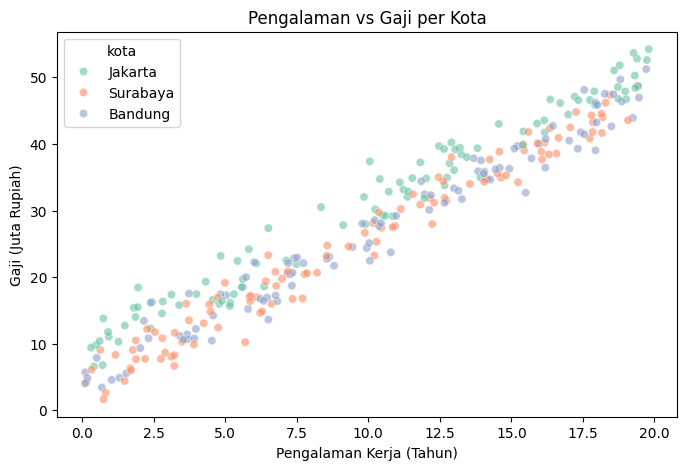

In [17]:
#VISUALISASI HUBUNGAN PENGALAMAN DAN GAJI

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2',
    alpha=0.6
)

plt.title("Pengalaman vs Gaji per Kota")
plt.xlabel("Pengalaman Kerja (Tahun)")
plt.ylabel("Gaji (Juta Rupiah)")

plt.show()

In [19]:
#ONE HOTE ECODING

df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print("Kolom Setelah Encoding")

print(df.columns.tolist())

df.head()

Kolom Setelah Encoding
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']


,pengalaman,edu,gaji,kota_Jakarta,kota_Surabaya
0,7.490802,0,21.953247,1,0
1,19.014286,1,46.721665,1,0
2,14.639879,2,34.952649,0,1
3,11.973170,2,32.437143,0,0
4,3.120373,2,17.384265,1,0


In [20]:
#MEMISAHKAN FITUR DAN TARGET

X = df.drop('gaji', axis=1)

y = df['gaji']

print("Fitur (X)")
print(X.head())

print("\nTarget (y)")
print(y.head())

Fitur (X)
   pengalaman  edu  kota_Jakarta  kota_Surabaya
0    7.490802    0             1              0
1   19.014286    1             1              0
2   14.639879    2             0              1
3   11.973170    2             0              0
4    3.120373    2             1              0

Target (y)
0    21.953247
1    46.721665
2    34.952649
3    32.437143
4    17.384265
Name: gaji, dtype: float64


In [21]:
#TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Jumlah Data Train :", X_train.shape[0])
print("Jumlah Data Test  :", X_test.shape[0])

Jumlah Data Train : 240
Jumlah Data Test  : 60


In [23]:
#FEATURE SCALING

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_test_s = scaler.transform(X_test)

print("Scaling Berhasil")

Scaling Berhasil


In [24]:
#MELATIH MODEL REGRESI LINEAR

model = LinearRegression()

model.fit(
    X_train_s,
    y_train
)

print("Model Berhasil Dilatih")

Model Berhasil Dilatih


In [25]:
#MENAMPILKAN KOEFISIEN

print("Intercept")

print(model.intercept_)

print()

coef_df = pd.DataFrame({
    'Fitur' : X.columns,
    'Koefisien' : model.coef_
})

coef_df = coef_df.sort_values(
    by='Koefisien',
    ascending=False
)

print(coef_df.to_string(index=False))

Intercept
27.514124756898322

        Fitur  Koefisien
   pengalaman  13.042241
 kota_Jakarta   1.837226
          edu   1.187879
kota_Surabaya  -0.291561


In [26]:
#PREDIKSI

y_pred = model.predict(X_test_s)

print("Contoh Hasil Prediksi")

hasil = pd.DataFrame({
    'Aktual': y_test.values,
    'Prediksi': y_pred
})

print(hasil.head())

Contoh Hasil Prediksi
      Aktual   Prediksi
0  43.231548  42.893800
1  37.527929  36.873847
2   8.654223  10.571370
3  34.733161  37.359908
4  32.040451  31.735946


In [29]:
#EVALUASI MODEL

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("=== HASIL EVALUASI ===")

print(f"MAE  = {mae:.3f}")

print(f"RMSE = {rmse:.3f}")

print(f"R2   = {r2:.4f}")

print()

print(f"Selisih RMSE-MAE = {rmse-mae:.3f}")

=== HASIL EVALUASI ===
MAE  = 1.649
RMSE = 2.123
R2   = 0.9740

Selisih RMSE-MAE = 0.474


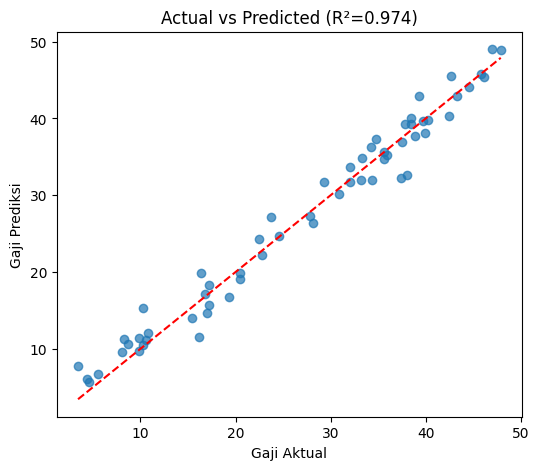

In [31]:
#ACTUAL VS PREDICTED

plt.figure(figsize=(6,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Gaji Aktual")

plt.ylabel("Gaji Prediksi")

plt.title(
    f"Actual vs Predicted (R²={r2:.3f})"
)

plt.show()


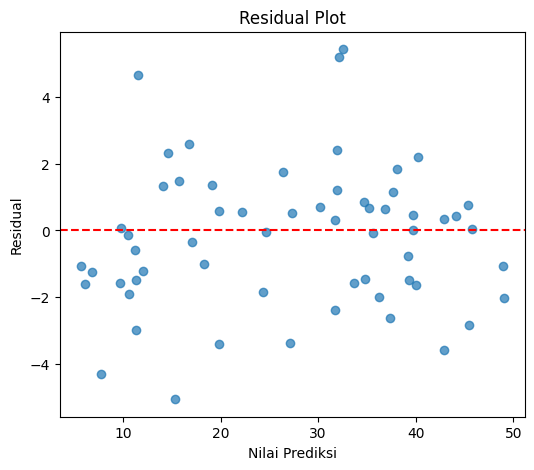

In [32]:
#RESIDUAL PLOT

residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.xlabel("Nilai Prediksi")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

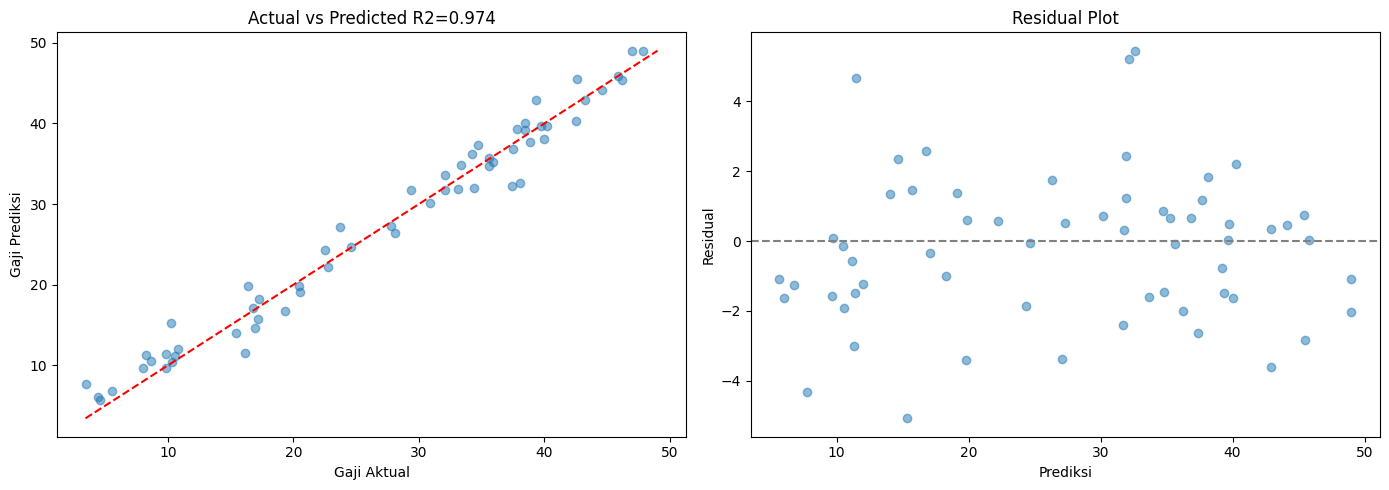

In [33]:
#SIMPAN GAMBAR

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# Actual vs Predicted
axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.5
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    'r--'
)

axes[0].set_title(
    f'Actual vs Predicted R2={r2:.3f}'
)

axes[0].set_xlabel(
    'Gaji Aktual'
)

axes[0].set_ylabel(
    'Gaji Prediksi'
)

# Residual Plot
axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.5
)

axes[1].axhline(
    0,
    color='gray',
    linestyle='--'
)

axes[1].set_title(
    'Residual Plot'
)

axes[1].set_xlabel(
    'Prediksi'
)

axes[1].set_ylabel(
    'Residual'
)

plt.tight_layout()

plt.savefig(
    'evaluasi_regresi.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

Berdasarkan hasil pengujian menggunakan model Regresi Linear, diperoleh nilai MAE yang menunjukkan rata-rata kesalahan prediksi model terhadap data aktual. Nilai RMSE yang tidak jauh berbeda dari MAE menunjukkan bahwa tidak terdapat outlier yang signifikan pada data. Selain itu, nilai R² yang mendekati 1 menunjukkan bahwa model mampu menjelaskan sebagian besar variasi data gaji dengan sangat baik.

Visualisasi Actual vs Predicted menunjukkan bahwa sebagian besar titik berada di sekitar garis diagonal, yang berarti hasil prediksi cukup mendekati nilai aktual. Sementara itu, Residual Plot menunjukkan penyebaran residual yang relatif acak di sekitar garis nol, sehingga asumsi linearitas model dapat dianggap terpenuhi.

Dengan demikian, model Regresi Linear berhasil digunakan untuk memprediksi gaji berdasarkan pengalaman kerja, tingkat pendidikan, dan kota tempat bekerja.